In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from IPython.display import Audio

from CustomSpeachDataset import CustomSpeachDataset
from augmentations import audio_transform, Noise, Gain, PitchShift, FadeIn, FadeOut

/home/dom/python_global_venvs/ML/venv/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [3]:
MODELS_DIR = Path("checkpoints")
MODELS_DIR.mkdir(exist_ok=True)

In [4]:
dataset = CustomSpeachDataset(Path("preprocessed_dataset"), preload=True)
dataset.to(device)

Preloading dataset from disk...


In [5]:
train_val_indices, test_indices = train_test_split(
    range(len(dataset)),
    test_size=0.2,
    stratify=dataset.y.cpu(),
    random_state=42
)

class_weights = 1.0 / dataset.label_counts
all_sample_weights = np.array([class_weights[y] for y in dataset.y.cpu()])

y_train = dataset.y.cpu()[train_val_indices]
train_val_dataset = torch.utils.data.Subset(dataset, train_val_indices)
train_val_sample_weights = all_sample_weights[train_val_indices]
len(train_val_dataset), len(y_train)

(14679, 14679)

In [6]:
add_noise = Noise(min_snr=0.001, max_snr=0.010).to(device)
pitch_shift = PitchShift(sample_rate=8000, min_steps=-3, max_steps=3).to(device)
amplitude_shift = Gain(0.5, 2.0).to(device)
fade_in = FadeIn()
fade_out = FadeOut()

In [7]:
samples, y = train_val_dataset[np.arange(32).tolist()]
samples = add_noise(samples)
samples.shape

torch.Size([32, 1, 8000])

In [8]:
Audio(samples[0].cpu(), rate=8000)

In [9]:
Audio(amplitude_shift(samples[0]).cpu(), rate=8000)

In [10]:
Audio(add_noise(samples[0]).cpu(), rate=8000)

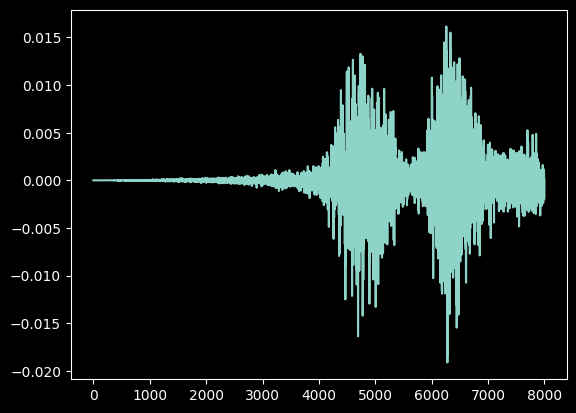

In [20]:
augmented = audio_transform(samples[0])
plt.plot(np.arange(8000), augmented[0].cpu())
plt.show()
Audio(augmented.cpu(), rate=8000)